# Loss Curve Prediction Across Learning-Rate Schedules

This notebook tests whether analytic scaling laws fitted on one learning-rate schedule can predict another schedule.

Main setting:

- fit on cosine;
- evaluate on WSD;
- compare One-Power, Tissue-style, and Multi-Power laws;
- diagnose phase-wise errors on WSD.


## 0. Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_loss_curve_pickle, names_by_label
from src.models import (
    fit_one_power_law,
    fit_single_scaling_law,
    fit_multi_power_law,
)
from src.metrics import (
    evaluate_fits,
    collect_predictions,
)
from src.plots import (
    plot_curves,
    plot_fit_overlay,
    plot_lr_with_phases,
    plot_error_curves,
    plot_metric_bars,
    plot_fit_zoom_compare,
    plot_error_compare,
    plot_metric_compare_bars,
)

plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [2]:
DATA_PATH = PROJECT_ROOT.parent / "loss curves" / "gpt_loss+lrs.pkl"

RESULT_DIR = PROJECT_ROOT / "results"
FIG_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "tables"

for path in [RESULT_DIR, FIG_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SMOOTH_WINDOW = 50

FIT_START = 1000
FIT_EVERY = 500
MPL_EVERY = 500
EVAL_EVERY = 100

MAX_STEPS_MPL = 2000
DEVICE = "cuda"  # change to "auto" or "cpu" if needed

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Figure dir:", FIG_DIR)
print("Table dir:", TABLE_DIR)

if not DATA_PATH.exists():
    raise FileNotFoundError(DATA_PATH)

Project root: f:\cls2_2\DLT\final_project\code
Data path: f:\cls2_2\DLT\final_project\loss curves\gpt_loss+lrs.pkl
Figure dir: f:\cls2_2\DLT\final_project\code\results\figures
Table dir: f:\cls2_2\DLT\final_project\code\results\tables


## 1. Load data and inspect schedules

The data contain three schedules: `cosine`, `wsd`, and `811`.

Preprocessing:

- missing steps are filled by interpolation / forward fill / backward fill;
- smoothed loss is used for fitting and evaluation;
- raw loss is kept only for visualization.


In [3]:
curves = load_loss_curve_pickle(
    DATA_PATH,
    smooth_window=SMOOTH_WINDOW,
)

curve_summary = pd.DataFrame(
    [
        {
            "source_key": source_key,
            "label": curve.label,
            "n_steps": len(curve.step),
            "start_step": int(curve.step[0]),
            "end_step": int(curve.step[-1]),
            "loss_start": float(curve.loss[0]),
            "loss_end": float(curve.loss[-1]),
            "lr_start": float(curve.lr[0]),
            "lr_end": float(curve.lr[-1]),
            "lr_min": float(curve.lr.min()),
            "lr_max": float(curve.lr.max()),
        }
        for source_key, curve in curves.items()
    ]
)

display(curve_summary)
curve_summary.to_csv(TABLE_DIR / "curve_summary.csv", index=False)

[prepare_curve] M:100M_gpt_D:20B_scheduler:wsd_rope: filled 1 missing step(s) by interpolation/ffill/bfill at: 20815
[prepare_curve] M:100M_gpt_D:20B_scheduler:cosine_rope: filled 1 missing step(s) by interpolation/ffill/bfill at: 22493


,source_key,label,n_steps,start_step,end_step,loss_start,loss_end,lr_start,lr_end,lr_min,lr_max
0,M:100M_gpt_D:20B_scheduler:811_rope,811,33908,0,33907,10.403171,2.663881,0.001,0.0001,0.0001,0.001
1,M:100M_gpt_D:20B_scheduler:wsd_rope,wsd,33908,0,33907,10.403172,2.658174,0.001,0.0001,0.0001,0.001
2,M:100M_gpt_D:20B_scheduler:cosine_rope,cosine,33908,0,33907,10.403172,2.667282,0.001,0.0001,0.0001,0.001


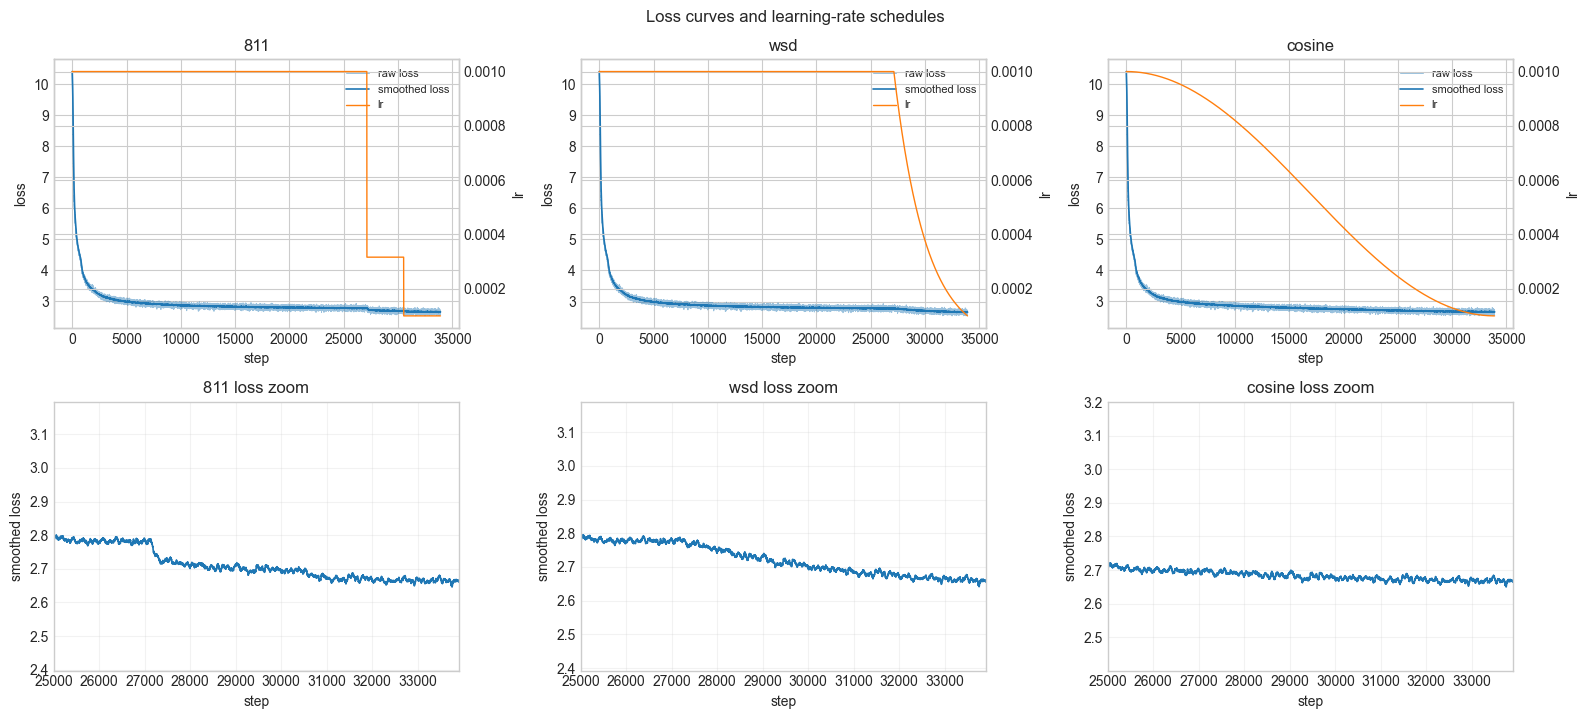

In [4]:
fig, axes = plot_curves(curves, figsize=(16, 7), zoom_start=25000)
fig.suptitle("Loss curves and learning-rate schedules", y=1.02)
fig.savefig(FIG_DIR / "data_overview.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Strict baseline: fit cosine, evaluate WSD

Course-required setting:

$$
\text{fit on cosine} \rightarrow \text{evaluate on WSD}.
$$

WSD is not used for fitting. The `811` schedule is kept for later diagnostic experiments.


In [5]:
train_names = names_by_label(curves, ["cosine"])
eval_names = names_by_label(curves, ["cosine", "wsd"])

wsd_name = names_by_label(curves, ["wsd"])[0]
wsd_curve = curves[wsd_name]

print("Train on:", train_names)
print("Evaluate on:", eval_names)

if len(train_names) != 1:
    raise ValueError(f"Expected exactly one cosine curve, got {train_names}")

if len(names_by_label(curves, ["wsd"])) != 1:
    raise ValueError("Expected exactly one WSD curve.")

Train on: ['M:100M_gpt_D:20B_scheduler:cosine_rope']
Evaluate on: ['M:100M_gpt_D:20B_scheduler:wsd_rope', 'M:100M_gpt_D:20B_scheduler:cosine_rope']


### 2.1 Fit analytic baselines

We compare three models:

$$
L(t)=L_0 + A S_1(t)^{-\alpha}
$$

$$
L(t)=L_0 + A S_1(t)^{-\alpha} - C S_2(t)
$$

$$
L(t)=L_0 + A S_1(t)^{-\alpha} - LD(t)
$$

They correspond to One-Power, Tissue-style, and Multi-Power laws.


In [6]:
one_fit = fit_one_power_law(
    curves,
    train_names=train_names,
    every=FIT_EVERY,
    start_step=FIT_START,
)

single_fit = fit_single_scaling_law(
    curves,
    train_names=train_names,
    every=FIT_EVERY,
    start_step=FIT_START,
)

mpl_fit = fit_multi_power_law(
    curves,
    train_names=train_names,
    every=MPL_EVERY,
    start_step=FIT_START,
    max_steps=MAX_STEPS_MPL,
    device=DEVICE,
)

fits = [one_fit, single_fit, mpl_fit]

param_table = pd.DataFrame(
    [
        {
            "method": fit.method,
            "train_names": ", ".join(fit.train_names),
            "fit_loss": fit.fit_loss,
            **fit.param_dict,
        }
        for fit in fits
    ]
)

display(param_table)
param_table.to_csv(TABLE_DIR / "baseline_params_cosine_only.csv", index=False)

,method,train_names,fit_loss,L0,A,alpha,C,B,beta,gamma
0,one_power,M:100M_gpt_D:20B_scheduler:cosine_rope,0.000505,1.948983,1.708731,0.283992,NaN,NaN,NaN,NaN
1,single,M:100M_gpt_D:20B_scheduler:cosine_rope,0.000080,2.781395,1.124848,1.034702,0.184625,NaN,NaN,NaN
2,mpl,M:100M_gpt_D:20B_scheduler:cosine_rope,0.000082,2.784238,1.122712,1.039902,0.634125,299.3253,0.305332,0.314252


### 2.2 Global WSD error

The table and bar plot summarize WSD prediction errors under cosine-only fitting.


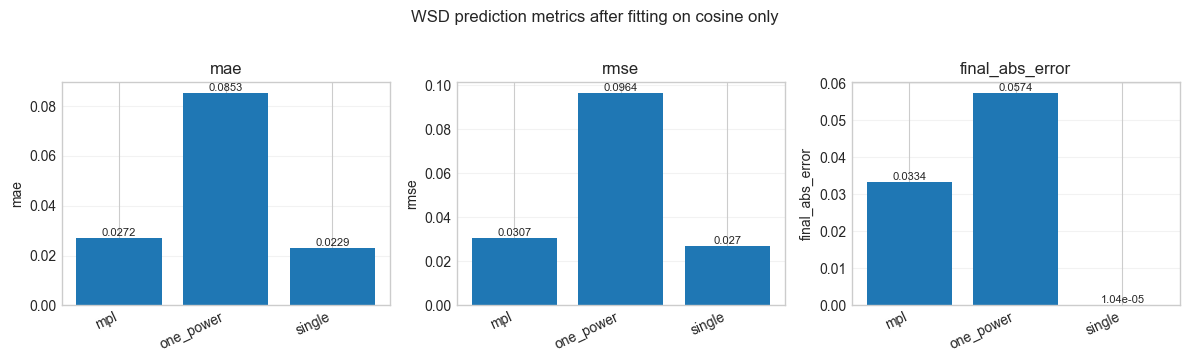

,method,mae,rmse,final_abs_error,r2
5,single,0.022935,0.027018,0.000010,0.976394
3,mpl,0.027191,0.030674,0.033401,0.969573
4,one_power,0.085254,0.096420,0.057406,0.699351


In [7]:
global_metrics = evaluate_fits(
    fits,
    curves,
    names=eval_names,
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

global_metrics = global_metrics.sort_values(["curve", "method"]).reset_index(drop=True)
global_metrics.to_csv(TABLE_DIR / "global_metrics_cosine_wsd.csv", index=False)

fig, axes = plot_metric_bars(
    global_metrics,
    curve_label="wsd",
    metric_cols=("mae", "rmse", "final_abs_error"),
    title="WSD prediction metrics after fitting on cosine only",
    figsize=(12, 3.5),
)
fig.savefig(FIG_DIR / "wsd_metrics_fit_cosine_only.png", dpi=200, bbox_inches="tight")
plt.show()

display(
    global_metrics[global_metrics["curve"].astype(str).str.lower() == "wsd"]
    [["method", "mae", "rmse", "final_abs_error", "r2"]]
    .sort_values("mae")
)

## 3. WSD prediction and residual under cosine-only fitting

We use the signed residual

$$
e_t=\hat L_t-L_t.
$$

Positive residual means the model over-predicts the WSD loss.


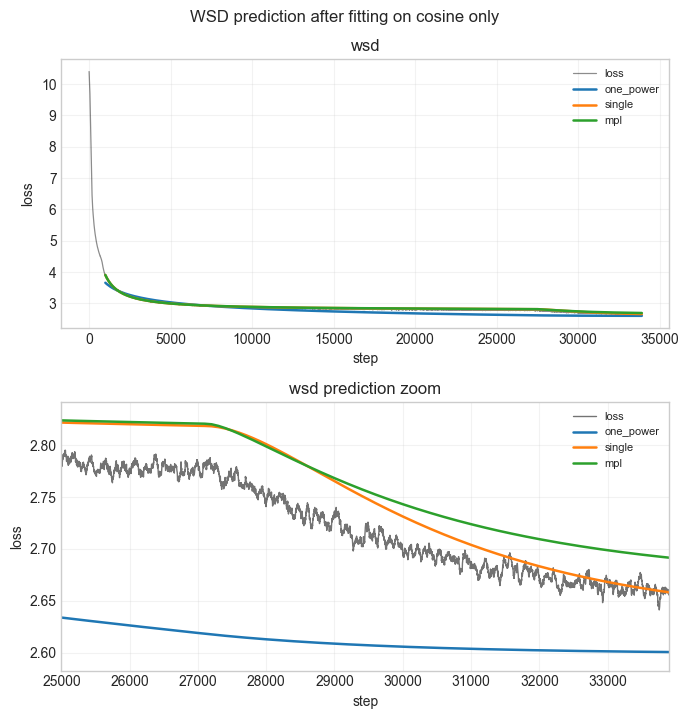

In [8]:
fig, axes = plot_fit_overlay(
    fits,
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
    figsize=(7, 7),
    zoom_start=25000,
)

fig.suptitle("WSD prediction after fitting on cosine only", y=1.02)
fig.savefig(FIG_DIR / "wsd_prediction_overlay_fit_cosine_only.png", dpi=200, bbox_inches="tight")
plt.show()

In [9]:
pred_df = collect_predictions(
    fits,
    curves,
    names=eval_names,
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

pred_df.to_csv(TABLE_DIR / "predictions_cosine_only.csv", index=False)

### 3.1 WSD phase annotation

WSD is split into:

- stable phase: before the first LR decrease;
- decay phase: after the first LR decrease.


In [10]:
def make_wsd_phase_masks(curve, atol=1e-12):
    """Simple phase annotation for a clean WSD schedule."""

    lr = np.asarray(curve.lr, dtype=np.float64)
    diff = np.diff(lr)

    decrease_idx = np.flatnonzero(diff < -atol)
    decay_start = int(decrease_idx[0] + 1) if len(decrease_idx) else len(lr)

    stable = np.zeros(len(lr), dtype=bool)
    decay = np.zeros(len(lr), dtype=bool)

    stable[:decay_start] = True
    decay[decay_start:] = True

    return {"stable": stable, "decay": decay}, decay_start


def attach_wsd_phase(pred_df, wsd_source_key, wsd_phase_masks, default_phase="not_wsd"):
    """Attach stable/decay labels to WSD rows only."""

    out = pred_df.copy()
    out["phase"] = default_phase

    phase_labels = np.full(len(curves[wsd_source_key].step), default_phase, dtype=object)
    for phase, mask in wsd_phase_masks.items():
        phase_labels[mask] = phase

    is_wsd = out["source_key"] == wsd_source_key
    steps = out.loc[is_wsd, "step"].to_numpy(dtype=int)
    out.loc[is_wsd, "phase"] = phase_labels[steps]

    return out


wsd_phase_masks, wsd_decay_start = make_wsd_phase_masks(wsd_curve)

print("WSD decay starts at step:", int(wsd_curve.step[wsd_decay_start]))
print("Stable steps:", int(wsd_phase_masks["stable"].sum()))
print("Decay steps:", int(wsd_phase_masks["decay"].sum()))

WSD decay starts at step: 27126
Stable steps: 27126
Decay steps: 6782


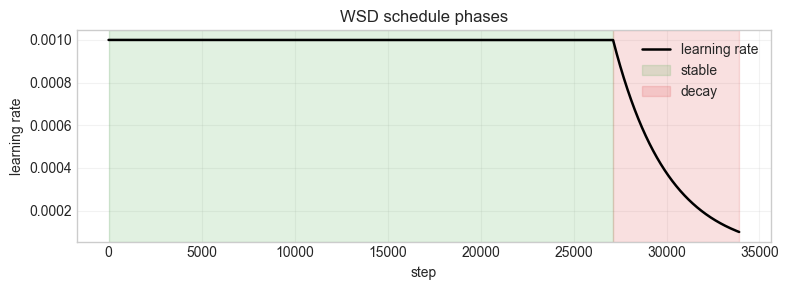

In [11]:
fig, ax = plot_lr_with_phases(
    wsd_curve,
    wsd_phase_masks,
    figsize=(8, 3),
    title="WSD schedule phases",
)

fig.savefig(FIG_DIR / "wsd_schedule_phases.png", dpi=200, bbox_inches="tight")
plt.show()

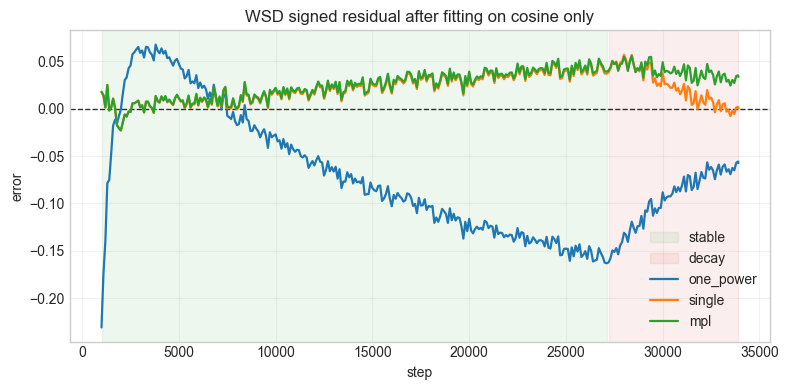

In [12]:
pred_df = attach_wsd_phase(
    pred_df,
    wsd_source_key=wsd_name,
    wsd_phase_masks=wsd_phase_masks,
)

pred_df.to_csv(TABLE_DIR / "predictions_cosine_only_with_phase.csv", index=False)

fig, ax = plot_error_curves(
    pred_df,
    curve_label="wsd",
    error_col="error",
    phase_col="phase",
    figsize=(8, 4),
    title="WSD signed residual after fitting on cosine only",
    phase_colors={
        "stable": "tab:green",
        "decay": "tab:red",
        "not_wsd": "tab:gray",
        "unknown": "tab:gray",
    },
)

fig.savefig(FIG_DIR / "wsd_signed_residual_fit_cosine_only.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Diagnostic comparison: three fitting settings

To diagnose the cosine-only error, we compare:

1. `cos`: cosine only;
2. `cos + 8-1-1`: cosine plus full `811`;
3. `cos + 8-1-1 const`: cosine plus only the constant segment of `811`.

This separates stable-plateau information from explicit LR-drop information.


In [13]:
def make_811_const_curve(curve, atol=1e-12):
    """Return only the first constant-LR segment of an 8-1-1 curve."""

    lr = np.asarray(curve.lr, dtype=np.float64)
    diff = np.diff(lr)

    drop_idx = np.flatnonzero(diff < -atol)
    if len(drop_idx) == 0:
        end = len(lr)
    else:
        end = int(drop_idx[0] + 1)

    return type(curve)(
        name=f"{curve.name}_const",
        step=curve.step[:end].copy(),
        loss=curve.loss[:end].copy(),
        lr=curve.lr[:end].copy(),
        raw_loss=curve.raw_loss[:end].copy(),
        label="811_const",
    )


def fit_baselines_for_setting(curves_for_fit, train_names_for_fit, setting_suffix):
    """Fit all three analytic baselines for one fitting setting."""

    one = fit_one_power_law(
        curves_for_fit,
        train_names=train_names_for_fit,
        every=FIT_EVERY,
        start_step=FIT_START,
    )

    single = fit_single_scaling_law(
        curves_for_fit,
        train_names=train_names_for_fit,
        every=FIT_EVERY,
        start_step=FIT_START,
    )

    mpl = fit_multi_power_law(
        curves_for_fit,
        train_names=train_names_for_fit,
        every=MPL_EVERY,
        start_step=FIT_START,
        max_steps=MAX_STEPS_MPL,
        device=DEVICE,
    )

    setting_fits = [one, single, mpl]

    for fit in setting_fits:
        fit.method = f"{fit.method} ({setting_suffix})"

    return setting_fits

In [14]:
# Setting 1: cosine only.
fits_cos = fits
for fit in fits_cos:
    if " (" not in fit.method:
        fit.method = f"{fit.method} (cos)"

# Setting 2: cosine + full 8-1-1.
train_names_cos_811_full = names_by_label(curves, ["cosine", "811"])
fits_cos_811_full = fit_baselines_for_setting(
    curves_for_fit=curves,
    train_names_for_fit=train_names_cos_811_full,
    setting_suffix="cos+811",
)

# Setting 3: cosine + constant segment of 8-1-1.
name_811 = names_by_label(curves, ["811"])[0]
curve_811_const = make_811_const_curve(curves[name_811])

curves_with_811_const = dict(curves)
curves_with_811_const["811_const"] = curve_811_const

train_names_cos_811_const = train_names + ["811_const"]
fits_cos_811_const = fit_baselines_for_setting(
    curves_for_fit=curves_with_811_const,
    train_names_for_fit=train_names_cos_811_const,
    setting_suffix="cos+811const",
)

print("Training settings:")
print("  cos:", train_names)
print("  cos + 8-1-1:", train_names_cos_811_full)
print("  cos + 8-1-1 const:", train_names_cos_811_const)
print("8-1-1 const segment ends at step:", int(curve_811_const.step[-1]))

Training settings:
  cos: ['M:100M_gpt_D:20B_scheduler:cosine_rope']
  cos + 8-1-1: ['M:100M_gpt_D:20B_scheduler:811_rope', 'M:100M_gpt_D:20B_scheduler:cosine_rope']
  cos + 8-1-1 const: ['M:100M_gpt_D:20B_scheduler:cosine_rope', '811_const']
8-1-1 const segment ends at step: 27125


In [15]:
def predict_wsd_for_setting(setting_fits):
    """Collect WSD predictions and attach phase labels."""

    out = collect_predictions(
        setting_fits,
        curves,
        names=[wsd_name],
        every=EVAL_EVERY,
        start_step=FIT_START,
        device=DEVICE,
    )

    out = attach_wsd_phase(
        out,
        wsd_source_key=wsd_name,
        wsd_phase_masks=wsd_phase_masks,
    )

    return out


pred_df_cos = pred_df[pred_df["source_key"] == wsd_name].copy()
pred_df_cos_811_full = predict_wsd_for_setting(fits_cos_811_full)
pred_df_cos_811_const = predict_wsd_for_setting(fits_cos_811_const)

metrics_cos_811_full = evaluate_fits(
    fits_cos_811_full,
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

metrics_cos_811_const = evaluate_fits(
    fits_cos_811_const,
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

fit_groups = {
    "cos": fits_cos,
    "cos + 8-1-1": fits_cos_811_full,
    "cos + 8-1-1 const": fits_cos_811_const,
}

pred_groups = {
    "cos": pred_df_cos,
    "cos + 8-1-1": pred_df_cos_811_full,
    "cos + 8-1-1 const": pred_df_cos_811_const,
}

metrics_by_setting = {
    "cos": global_metrics,
    "cos + 8-1-1": metrics_cos_811_full,
    "cos + 8-1-1 const": metrics_cos_811_const,
}

setting_linestyles = {
    "cos": "-",
    "cos + 8-1-1": "--",
    "cos + 8-1-1 const": ":",
}

### 4.1 Prediction zoom under three fitting settings


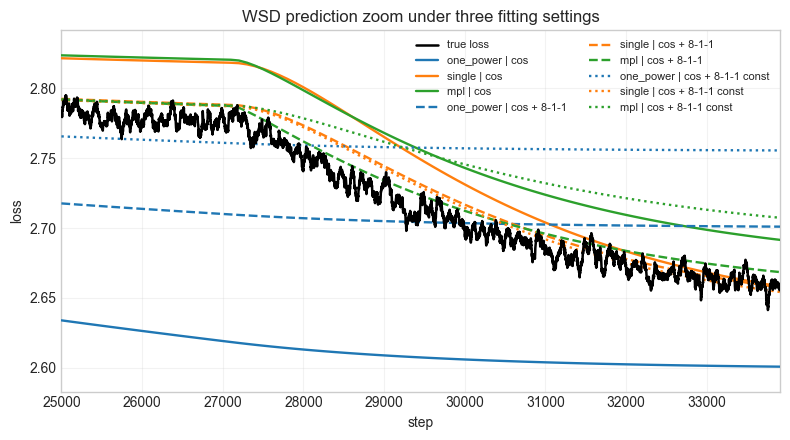

In [16]:
fig, ax = plot_fit_zoom_compare(
    fit_groups=fit_groups,
    curve=wsd_curve,
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
    zoom_start=25000,
    figsize=(8, 4.5),
    title="WSD prediction zoom under three fitting settings",
    setting_linestyles=setting_linestyles,
)

fig.savefig(FIG_DIR / "compare_three_settings_wsd_prediction_zoom.png", dpi=200, bbox_inches="tight")
plt.show()

### 4.2 Signed residual under three fitting settings

This is the main diagnostic plot.

- Improvement from `8-1-1 const` indicates better stable-phase calibration.
- Additional improvement from full `8-1-1` indicates useful LR-drop information.


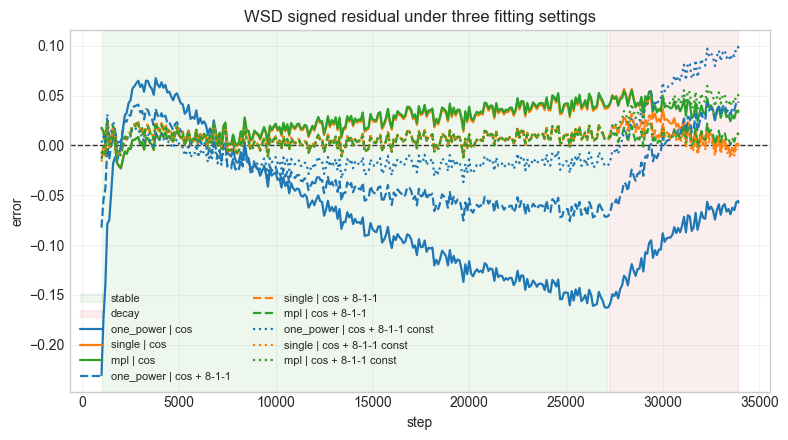

In [17]:
fig, ax = plot_error_compare(
    pred_groups=pred_groups,
    curve_label="wsd",
    error_col="error",
    phase_col="phase",
    figsize=(8, 4.5),
    title="WSD signed residual under three fitting settings",
    setting_linestyles=setting_linestyles,
    phase_colors={
        "stable": "tab:green",
        "decay": "tab:red",
        "not_wsd": "tab:gray",
        "unknown": "tab:gray",
    },
)

fig.savefig(FIG_DIR / "compare_three_settings_wsd_signed_residual.png", dpi=200, bbox_inches="tight")
plt.show()

### 4.3 Compact WSD metric summary

The bar plot summarizes the residual and prediction results numerically.


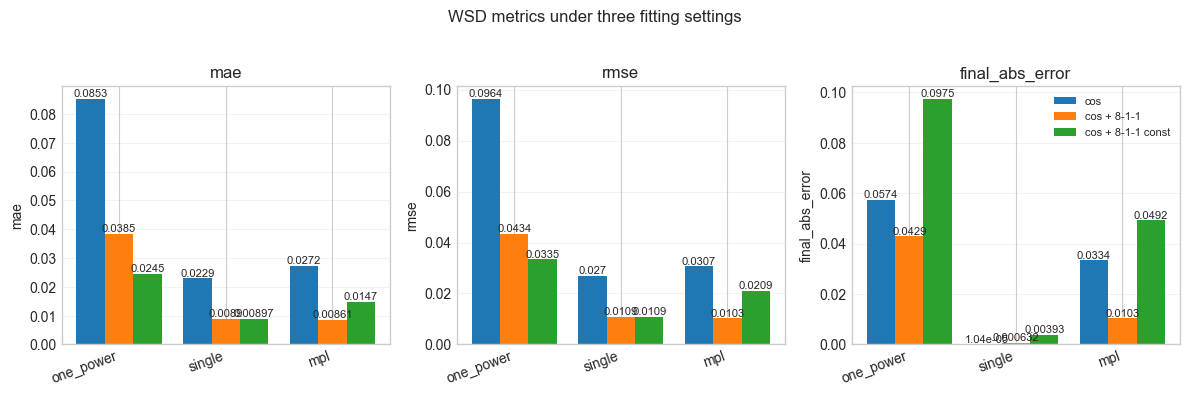

In [18]:
fig, axes = plot_metric_compare_bars(
    metrics_by_setting=metrics_by_setting,
    curve_label="wsd",
    metric_cols=("mae", "rmse", "final_abs_error"),
    figsize=(12, 3.8),
    title="WSD metrics under three fitting settings",
)

fig.savefig(FIG_DIR / "compare_three_settings_wsd_metric_bars.png", dpi=200, bbox_inches="tight")
plt.show()

### 4.4 Stable-phase residual slope

To quantify stable-phase drift, we fit

$$
e_t \approx a + b\frac{t-t_0}{1000}
$$

on the WSD stable phase after step 10,000.

The slope \(b\) is residual drift per 1,000 steps.


In [19]:
def base_method_name(method: str) -> str:
    """Normalize method names across fitting settings."""

    method = str(method)
    method = method.split(" (")[0]
    method = method.replace("tissue_momentum", "single")
    method = method.replace("multi_power", "mpl")
    return method


def linear_r2(y_true, y_pred) -> float:
    """R^2 of a one-dimensional linear fit."""

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot <= 0:
        return np.nan

    return float(1.0 - ss_res / ss_tot)


def compute_stable_residual_slopes(pred_groups, min_step: int = 10000):
    """Fit e_t = a + b * ((t - t0) / 1000) on WSD stable phase.

    Only use stable-phase points with step >= min_step.

    slope is residual drift per 1000 training steps.
    R^2 measures how well the stable-phase residual is approximated by a line.
    """

    rows = []

    for setting, df in pred_groups.items():
        stable_df = df[
            (df["curve"].astype(str).str.lower() == "wsd")
            & (df["phase"] == "stable")
            & (df["step"] >= min_step)
        ].copy()

        for method, group in stable_df.groupby("method", sort=False):
            group = group.sort_values("step")

            x = group["step"].to_numpy(dtype=float)
            y = group["error"].to_numpy(dtype=float)

            if len(group) < 2:
                continue

            x_1k = (x - x.min()) / 1000.0
            slope, intercept = np.polyfit(x_1k, y, deg=1)

            y_fit = intercept + slope * x_1k
            r2 = linear_r2(y, y_fit)

            rows.append(
                {
                    "setting": setting,
                    "method": base_method_name(method),
                    "fit_step_min": int(x.min()),
                    "fit_step_max": int(x.max()),
                    "stable_slope_per_1k_steps": float(slope),
                    "stable_intercept": float(intercept),
                    "stable_linear_r2": float(r2),
                    "n_points": int(len(group)),
                }
            )

    return pd.DataFrame(rows)


stable_slope_df = compute_stable_residual_slopes(
    pred_groups,
    min_step=10000,
)

display(
    stable_slope_df.sort_values(["method", "setting"])
)

stable_slope_df.to_csv(TABLE_DIR / "stable_residual_slope_after_10000.csv", index=False)

,setting,method,fit_step_min,fit_step_max,stable_slope_per_1k_steps,stable_intercept,stable_linear_r2,n_points
2,cos,mpl,10000,27100,0.001641,0.017647,0.684300,172
5,cos + 8-1-1,mpl,10000,27100,0.000527,0.001728,0.182956,172
8,cos + 8-1-1 const,mpl,10000,27100,0.000599,0.000958,0.224440,172
0,cos,one_power,10000,27100,-0.007084,-0.045449,0.958164,172
3,cos + 8-1-1,one_power,10000,27100,-0.002148,-0.033945,0.755144,172
6,cos + 8-1-1 const,one_power,10000,27100,0.000197,-0.019795,0.029864,172
1,cos,single,10000,27100,0.001601,0.016118,0.673783,172
4,cos + 8-1-1,single,10000,27100,0.000613,0.001183,0.232765,172
7,cos + 8-1-1 const,single,10000,27100,0.000497,0.001985,0.165917,172


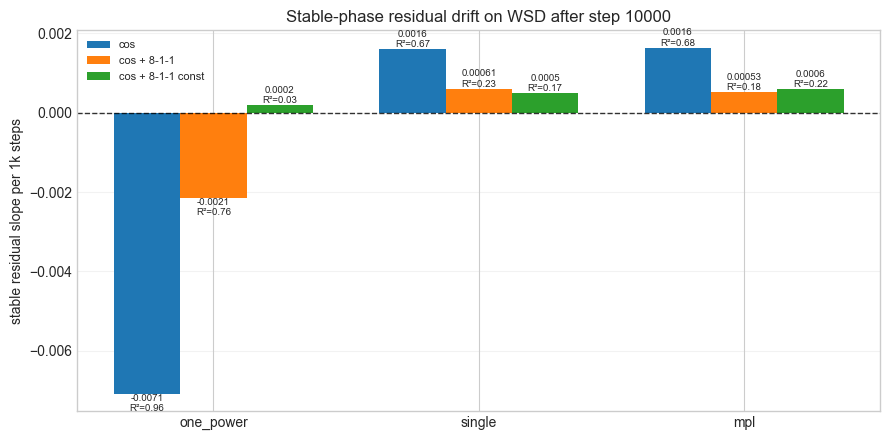

In [20]:
method_order = ["one_power", "single", "mpl"]
setting_order = list(pred_groups.keys())

slope_pivot = stable_slope_df.pivot_table(
    index="method",
    columns="setting",
    values="stable_slope_per_1k_steps",
    aggfunc="mean",
).reindex(method_order)

r2_pivot = stable_slope_df.pivot_table(
    index="method",
    columns="setting",
    values="stable_linear_r2",
    aggfunc="mean",
).reindex(method_order)

fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(method_order))
width = min(0.8 / len(setting_order), 0.25)

for i, setting in enumerate(setting_order):
    values = slope_pivot[setting].to_numpy(dtype=float)
    r2_values = r2_pivot[setting].to_numpy(dtype=float)

    offset = (i - (len(setting_order) - 1) / 2) * width

    ax.bar(
        x + offset,
        values,
        width=width,
        label=setting,
    )

    for xi, value, r2 in zip(x + offset, values, r2_values):
        if not np.isfinite(value):
            continue

        label = f"{value:.2g}\nR²={r2:.2f}" if np.isfinite(r2) else f"{value:.2g}\nR²=NA"

        ax.text(
            xi,
            value,
            label,
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=7,
        )

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(method_order)
ax.set_ylabel("stable residual slope per 1k steps")
ax.set_title("Stable-phase residual drift on WSD after step 10000")
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "stable_residual_slope_after_10000.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Decoupled Tissue-style fitting

We test whether separating base dynamics and LR-decay correction improves WSD transfer.

Stage 1: fit the base term on the constant segment of `811`:

$$
L_{\mathrm{base}}(t)=L_0 + A S_1(t)^{-\alpha}.
$$

Stage 2: fix $L_0,A,\alpha$, and fit only $C$ on cosine:

$$
L(t)=L_{\mathrm{base}}(t)-C S_2(t).
$$

This uses the same information sources as `cos + 8-1-1 const`, but reduces parameter coupling.


In [21]:
from src.models import fit_decoupled_single_scaling_law

In [22]:
if "curves_with_811_const" not in globals():
    if "make_811_const_curve" not in globals():
        def make_811_const_curve(curve, atol=1e-12):
            lr = np.asarray(curve.lr, dtype=np.float64)
            diff = np.diff(lr)
            drop_idx = np.flatnonzero(diff < -atol)
            end = int(drop_idx[0] + 1) if len(drop_idx) else len(lr)
            return type(curve)(
                name=f"{curve.name}_const",
                step=curve.step[:end].copy(),
                loss=curve.loss[:end].copy(),
                lr=curve.lr[:end].copy(),
                raw_loss=curve.raw_loss[:end].copy(),
                label="811_const",
            )

    name_811 = names_by_label(curves, ["811"])[0]
    curve_811_const = make_811_const_curve(curves[name_811])

    curves_with_811_const = dict(curves)
    curves_with_811_const["811_const"] = curve_811_const

if "decoupled_base_train_names" not in globals():
    decoupled_base_train_names = ["811_const"]

if "decoupled_correction_train_names" not in globals():
    decoupled_correction_train_names = train_names

print("Base fit curves:", decoupled_base_train_names)
print("Correction fit curves:", decoupled_correction_train_names)


Base fit curves: ['811_const']
Correction fit curves: ['M:100M_gpt_D:20B_scheduler:cosine_rope']


In [23]:
decoupled_single_fit = fit_decoupled_single_scaling_law(
    curves=curves_with_811_const,
    base_train_names=decoupled_base_train_names,
    correction_train_names=decoupled_correction_train_names,
    base_every=FIT_EVERY,
    correction_every=FIT_EVERY,
    start_step=FIT_START,
    decay_factor=0.999,
    huber_delta=1e-3,
)

decoupled_single_fit.method = "single (decoupled)"

print("Decoupled Tissue parameters:")
print(decoupled_single_fit.param_dict)


Decoupled Tissue parameters:
{'L0': 2.7219356740652763, 'A': 1.1482430988585022, 'C': 0.14888964898825124, 'alpha': 0.879375101762886, 'base_fit_loss': 8.530799591491217e-05, 'correction_fit_loss': 0.0001346324797551688}


In [24]:
pred_df_decoupled_single = collect_predictions(
    [decoupled_single_fit],
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

pred_df_decoupled_single = attach_wsd_phase(
    pred_df_decoupled_single,
    wsd_source_key=wsd_name,
    wsd_phase_masks=wsd_phase_masks,
)

metrics_decoupled_single = evaluate_fits(
    [decoupled_single_fit],
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

display(metrics_decoupled_single)
metrics_decoupled_single.to_csv(TABLE_DIR / "decoupled_single_wsd_metrics.csv", index=False)
pred_df_decoupled_single.to_csv(TABLE_DIR / "decoupled_single_wsd_predictions.csv", index=False)

,method,source_key,curve,n,step_start,step_end,mae,rmse,mape,worst_ape,r2,final_true,final_pred,final_error,final_abs_error,final_rel_error
0,single (decoupled),M:100M_gpt_D:20B_scheduler:wsd_rope,wsd,331,1000,33907,0.008428,0.010449,0.002937,0.010415,0.99647,2.658174,2.653562,-0.004611,0.004611,0.001735


### 5.1 Compare Tissue-style variants

Variants compared:

1. joint fit on cosine;
2. joint fit on cosine + full `811`;
3. joint fit on cosine + `811` constant segment;
4. decoupled fit: base on `811 const`, correction on cosine.


In [25]:
def get_base_method(method: str) -> str:
    method = str(method).split(" (")[0]
    method = method.replace("tissue_momentum", "single")
    method = method.replace("multi_power", "mpl")
    return method


def select_fit_by_base_method(fits, base_method):
    matches = [
        fit for fit in fits
        if get_base_method(getattr(fit, "method", fit.__class__.__name__)) == base_method
    ]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one {base_method!r} fit, found {len(matches)}")
    return matches[0]


single_cos = select_fit_by_base_method(fits_cos if "fits_cos" in globals() else fits, "single")
single_cos811 = select_fit_by_base_method(fits_cos_811_full, "single")
single_cos811const = select_fit_by_base_method(fits_cos_811_const, "single")

single_fit_groups = {
    "cos": [single_cos],
    "cos + 8-1-1": [single_cos811],
    "cos + 8-1-1 const": [single_cos811const],
    "decoupled": [decoupled_single_fit],
}

single_pred_groups = {
    "cos": pred_df_cos if "pred_df_cos" in globals() else pred_df[pred_df["source_key"] == wsd_name].copy(),
    "cos + 8-1-1": pred_df_cos_811_full,
    "cos + 8-1-1 const": pred_df_cos_811_const,
    "decoupled": pred_df_decoupled_single,
}

single_metrics_by_setting = {
    "cos": global_metrics,
    "cos + 8-1-1": metrics_cos_811_full,
    "cos + 8-1-1 const": metrics_cos_811_const,
    "decoupled": metrics_decoupled_single,
}

single_setting_linestyles = {
    "cos": "-",
    "cos + 8-1-1": "--",
    "cos + 8-1-1 const": ":",
    "decoupled": "-.",
}

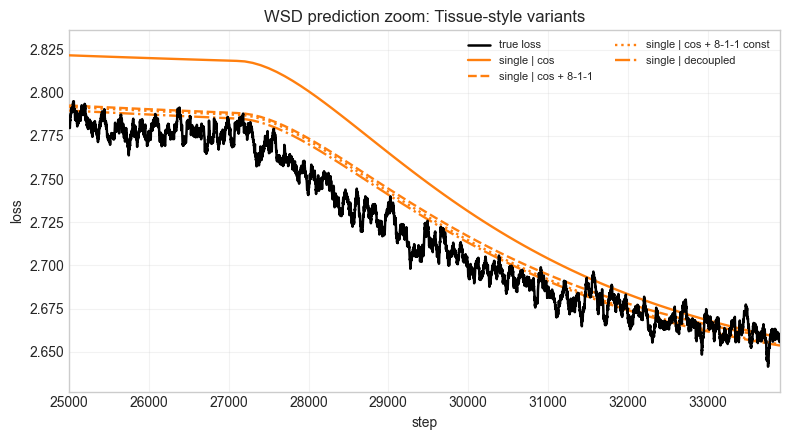

In [26]:
fig, ax = plot_fit_zoom_compare(
    fit_groups=single_fit_groups,
    curve=wsd_curve,
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
    zoom_start=25000,
    figsize=(8, 4.5),
    title="WSD prediction zoom: Tissue-style variants",
    setting_linestyles=single_setting_linestyles,
)

fig.savefig(FIG_DIR / "decoupled_single_wsd_prediction_zoom.png", dpi=200, bbox_inches="tight")
plt.show()

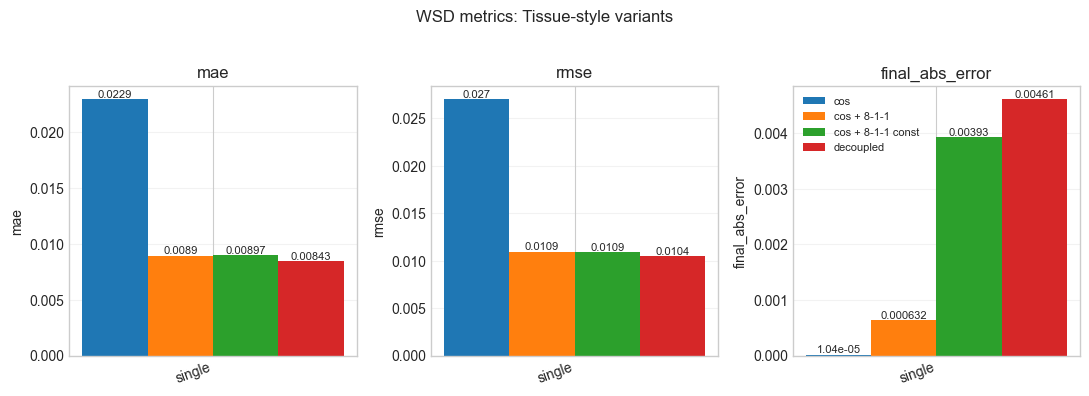

In [27]:
fig, axes = plot_metric_compare_bars(
    metrics_by_setting=single_metrics_by_setting,
    curve_label="wsd",
    metric_cols=("mae", "rmse", "final_abs_error"),
    method_order=("single",),
    figsize=(11, 3.8),
    title="WSD metrics: Tissue-style variants",
)

fig.savefig(FIG_DIR / "decoupled_single_wsd_metrics_bar.png", dpi=200, bbox_inches="tight")
plt.show()

### 5.2 Stable-phase residual slope after decoupling


,setting,method,fit_step_min,fit_step_max,stable_slope_per_1k_steps,stable_intercept,stable_linear_r2,n_points
0,cos,one_power,10000,27100,-0.007084,-0.045449,0.958164,172
1,cos,single,10000,27100,0.001601,0.016118,0.673783,172
2,cos,mpl,10000,27100,0.001641,0.017647,0.684300,172
3,cos + 8-1-1,one_power,10000,27100,-0.002148,-0.033945,0.755144,172
4,cos + 8-1-1,single,10000,27100,0.000613,0.001183,0.232765,172
5,cos + 8-1-1,mpl,10000,27100,0.000527,0.001728,0.182956,172
6,cos + 8-1-1 const,one_power,10000,27100,0.000197,-0.019795,0.029864,172
7,cos + 8-1-1 const,single,10000,27100,0.000497,0.001985,0.165917,172
8,cos + 8-1-1 const,mpl,10000,27100,0.000599,0.000958,0.224440,172
9,decoupled,single,10000,27100,0.000396,0.001376,0.111669,172


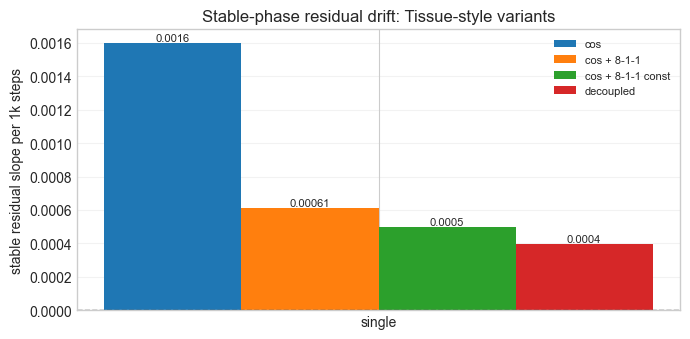

In [28]:
single_slope_df = compute_stable_residual_slopes(single_pred_groups)
display(single_slope_df)

single_slope_df.to_csv(TABLE_DIR / "decoupled_single_stable_residual_slope.csv", index=False)

method_order = ["single"]
setting_order = list(single_pred_groups.keys())

pivot = single_slope_df.pivot_table(
    index="method",
    columns="setting",
    values="stable_slope_per_1k_steps",
    aggfunc="mean",
).reindex(method_order)

fig, ax = plt.subplots(figsize=(7, 3.5))

x = np.arange(len(method_order))
width = min(0.8 / len(setting_order), 0.22)

for i, setting in enumerate(setting_order):
    values = pivot[setting].to_numpy(dtype=float)
    offset = (i - (len(setting_order) - 1) / 2) * width

    ax.bar(x + offset, values, width=width, label=setting)

    for xi, value in zip(x + offset, values):
        ax.text(
            xi,
            value,
            f"{value:.2g}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=8,
        )

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(method_order)
ax.set_ylabel("stable residual slope per 1k steps")
ax.set_title("Stable-phase residual drift: Tissue-style variants")
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "decoupled_single_stable_residual_slope.png", dpi=200, bbox_inches="tight")
plt.show()

**Interpretation.**

The decoupled Tissue-style model is close to the joint `cos + 8-1-1 const` fit, with a small improvement. This suggests that most of the gain comes from calibrating the base dynamics on a constant-LR regime.


## 6. Decoupled Multi-Power Law fitting

We apply the same separation to MPL.

Stage 1: fit the base one-power term on `811 const`:

$$
L_{\mathrm{base}}(t)=L_0+A S_1(t)^{-\alpha}.
$$

Stage 2: fix the base parameters and fit only MPL decay parameters on cosine.

This tests whether reducing parameter coupling helps the more flexible MPL form.


In [29]:
from src.models import fit_decoupled_multi_power_law

In [30]:
# Fallback helpers in case this section is run without the previous decoupled Tissue section.
if "curves_with_811_const" not in globals():
    if "make_811_const_curve" not in globals():
        def make_811_const_curve(curve, atol=1e-12):
            lr = np.asarray(curve.lr, dtype=np.float64)
            diff = np.diff(lr)
            drop_idx = np.flatnonzero(diff < -atol)
            end = int(drop_idx[0] + 1) if len(drop_idx) else len(lr)
            return type(curve)(
                name=f"{curve.name}_const",
                step=curve.step[:end].copy(),
                loss=curve.loss[:end].copy(),
                lr=curve.lr[:end].copy(),
                raw_loss=curve.raw_loss[:end].copy(),
                label="811_const",
            )

    name_811 = names_by_label(curves, ["811"])[0]
    curve_811_const = make_811_const_curve(curves[name_811])

    curves_with_811_const = dict(curves)
    curves_with_811_const["811_const"] = curve_811_const

if "decoupled_base_train_names" not in globals():
    decoupled_base_train_names = ["811_const"]

if "decoupled_correction_train_names" not in globals():
    decoupled_correction_train_names = train_names

print("Base fit curves:", decoupled_base_train_names)
print("Correction fit curves:", decoupled_correction_train_names)


Base fit curves: ['811_const']
Correction fit curves: ['M:100M_gpt_D:20B_scheduler:cosine_rope']


In [31]:
decoupled_mpl_fit = fit_decoupled_multi_power_law(
    curves=curves_with_811_const,
    base_train_names=decoupled_base_train_names,
    correction_train_names=decoupled_correction_train_names,
    base_every=FIT_EVERY,
    correction_every=MPL_EVERY,
    start_step=FIT_START,
    init_decay_params=(300.0, 1.0, 0.5, 0.5),
    max_steps=MAX_STEPS_MPL,
    lr_main=5e-2,
    lr_exp=5e-3,
    huber_delta=1e-3,
    patience=80,
    device=DEVICE,
    verbose=False,
)

decoupled_mpl_fit.method = "mpl (decoupled)"

print("Decoupled MPL parameters:")
print(decoupled_mpl_fit.param_dict)


Decoupled MPL parameters:
{'L0': 2.7219356740652763, 'A': 1.1482430988585022, 'alpha': 0.879375101762886, 'B': 301.90663133515227, 'C': 0.0009620534883519785, 'beta': 0.520810152458214, 'gamma': 0.8903121517300757, 'base_fit_loss': 8.530799591491217e-05, 'correction_fit_loss': 0.00011169228478944904}


In [32]:
pred_df_decoupled_mpl = collect_predictions(
    [decoupled_mpl_fit],
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

pred_df_decoupled_mpl = attach_wsd_phase(
    pred_df_decoupled_mpl,
    wsd_source_key=wsd_name,
    wsd_phase_masks=wsd_phase_masks,
)

metrics_decoupled_mpl = evaluate_fits(
    [decoupled_mpl_fit],
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

display(metrics_decoupled_mpl)
metrics_decoupled_mpl.to_csv(TABLE_DIR / "decoupled_mpl_wsd_metrics.csv", index=False)
pred_df_decoupled_mpl.to_csv(TABLE_DIR / "decoupled_mpl_wsd_predictions.csv", index=False)

,method,source_key,curve,n,step_start,step_end,mae,rmse,mape,worst_ape,r2,final_true,final_pred,final_error,final_abs_error,final_rel_error
0,mpl (decoupled),M:100M_gpt_D:20B_scheduler:wsd_rope,wsd,331,1000,33907,0.014399,0.020469,0.00516,0.021749,0.986451,2.658174,2.703215,0.045041,0.045041,0.016944


### 6.1 Compare MPL variants

Variants compared:

1. joint MPL fit on cosine;
2. joint MPL fit on cosine + full `811`;
3. joint MPL fit on cosine + `811` constant segment;
4. decoupled MPL: base on `811 const`, decay term on cosine.


In [33]:
def get_base_method(method: str) -> str:
    method = str(method).split(" (")[0]
    method = method.replace("tissue_momentum", "single")
    method = method.replace("multi_power", "mpl")
    return method


def select_fit_by_base_method(fits, base_method):
    matches = [
        fit for fit in fits
        if get_base_method(getattr(fit, "method", fit.__class__.__name__)) == base_method
    ]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one {base_method!r} fit, found {len(matches)}")
    return matches[0]


mpl_cos = select_fit_by_base_method(fits_cos if "fits_cos" in globals() else fits, "mpl")
mpl_cos811 = select_fit_by_base_method(fits_cos_811_full, "mpl")
mpl_cos811const = select_fit_by_base_method(fits_cos_811_const, "mpl")

mpl_fit_groups = {
    "cos": [mpl_cos],
    "cos + 8-1-1": [mpl_cos811],
    "cos + 8-1-1 const": [mpl_cos811const],
    "decoupled": [decoupled_mpl_fit],
}

mpl_pred_groups = {
    "cos": pred_df_cos if "pred_df_cos" in globals() else pred_df[pred_df["source_key"] == wsd_name].copy(),
    "cos + 8-1-1": pred_df_cos_811_full,
    "cos + 8-1-1 const": pred_df_cos_811_const,
    "decoupled": pred_df_decoupled_mpl,
}

mpl_metrics_by_setting = {
    "cos": global_metrics,
    "cos + 8-1-1": metrics_cos_811_full,
    "cos + 8-1-1 const": metrics_cos_811_const,
    "decoupled": metrics_decoupled_mpl,
}

mpl_setting_linestyles = {
    "cos": "-",
    "cos + 8-1-1": "--",
    "cos + 8-1-1 const": ":",
    "decoupled": "-.",
}

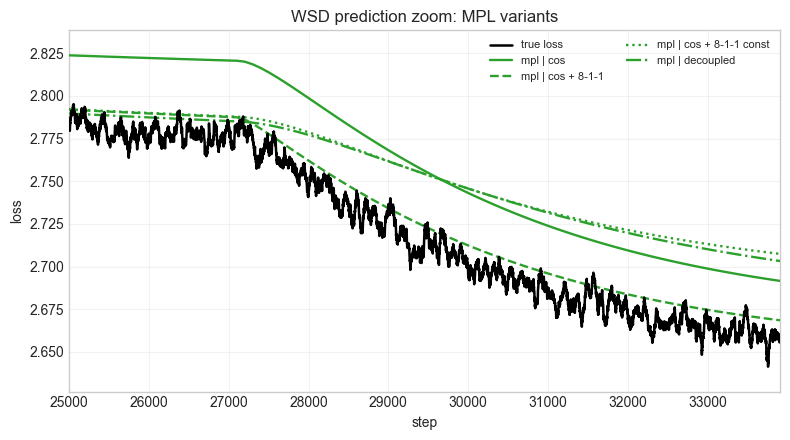

In [34]:
fig, ax = plot_fit_zoom_compare(
    fit_groups=mpl_fit_groups,
    curve=wsd_curve,
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
    zoom_start=25000,
    figsize=(8, 4.5),
    title="WSD prediction zoom: MPL variants",
    setting_linestyles=mpl_setting_linestyles,
)

fig.savefig(FIG_DIR / "decoupled_mpl_wsd_prediction_zoom.png", dpi=200, bbox_inches="tight")
plt.show()

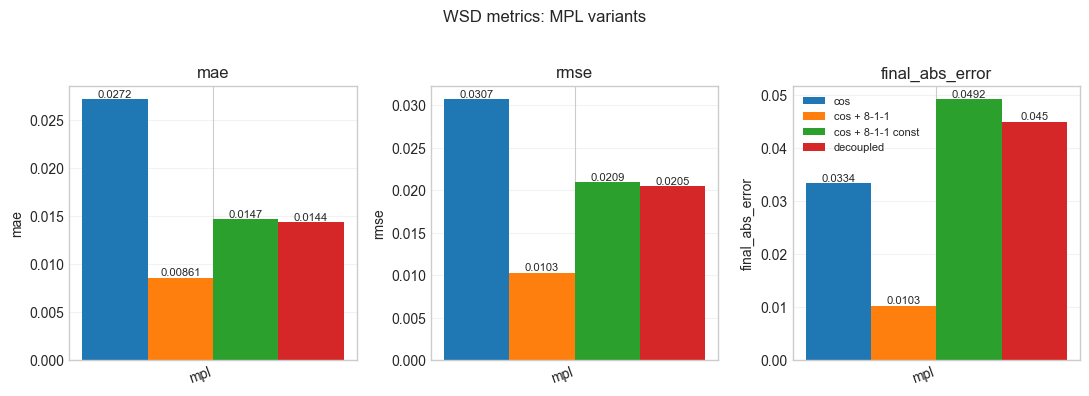

In [35]:
fig, axes = plot_metric_compare_bars(
    metrics_by_setting=mpl_metrics_by_setting,
    curve_label="wsd",
    metric_cols=("mae", "rmse", "final_abs_error"),
    method_order=("mpl",),
    figsize=(11, 3.8),
    title="WSD metrics: MPL variants",
)

fig.savefig(FIG_DIR / "decoupled_mpl_wsd_metrics_bar.png", dpi=200, bbox_inches="tight")
plt.show()

### 6.2 Stable-phase residual slope after MPL decoupling


,setting,method,fit_step_min,fit_step_max,stable_slope_per_1k_steps,stable_intercept,stable_linear_r2,n_points
0,cos,one_power,10000,27100,-0.007084,-0.045449,0.958164,172
1,cos,single,10000,27100,0.001601,0.016118,0.673783,172
2,cos,mpl,10000,27100,0.001641,0.017647,0.684300,172
3,cos + 8-1-1,one_power,10000,27100,-0.002148,-0.033945,0.755144,172
4,cos + 8-1-1,single,10000,27100,0.000613,0.001183,0.232765,172
5,cos + 8-1-1,mpl,10000,27100,0.000527,0.001728,0.182956,172
6,cos + 8-1-1 const,one_power,10000,27100,0.000197,-0.019795,0.029864,172
7,cos + 8-1-1 const,single,10000,27100,0.000497,0.001985,0.165917,172
8,cos + 8-1-1 const,mpl,10000,27100,0.000599,0.000958,0.224440,172
9,decoupled,mpl,10000,27100,0.000396,0.001376,0.111669,172


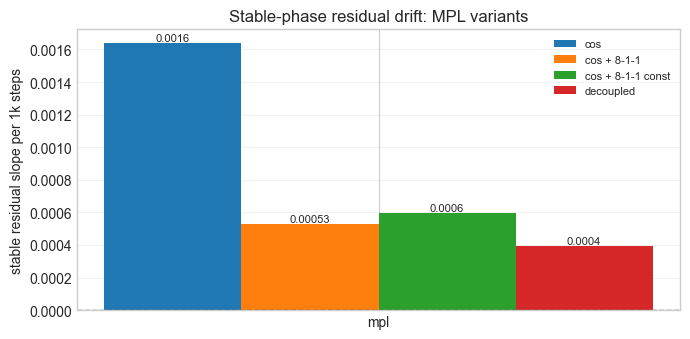

In [36]:
mpl_slope_df = compute_stable_residual_slopes(mpl_pred_groups)
display(mpl_slope_df)

mpl_slope_df.to_csv(TABLE_DIR / "decoupled_mpl_stable_residual_slope.csv", index=False)

method_order = ["mpl"]
setting_order = list(mpl_pred_groups.keys())

pivot = mpl_slope_df.pivot_table(
    index="method",
    columns="setting",
    values="stable_slope_per_1k_steps",
    aggfunc="mean",
).reindex(method_order)

fig, ax = plt.subplots(figsize=(7, 3.5))

x = np.arange(len(method_order))
width = min(0.8 / len(setting_order), 0.22)

for i, setting in enumerate(setting_order):
    values = pivot[setting].to_numpy(dtype=float)
    offset = (i - (len(setting_order) - 1) / 2) * width

    ax.bar(x + offset, values, width=width, label=setting)

    for xi, value in zip(x + offset, values):
        ax.text(
            xi,
            value,
            f"{value:.2g}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=8,
        )

ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(method_order)
ax.set_ylabel("stable residual slope per 1k steps")
ax.set_title("Stable-phase residual drift: MPL variants")
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "decoupled_mpl_stable_residual_slope.png", dpi=200, bbox_inches="tight")
plt.show()

**Interpretation.**

Decoupled MPL slightly improves over joint `cos + 8-1-1 const`, but it remains worse than MPL trained with full `811`. This indicates that MPL still needs explicit decay examples to identify its flexible decay term.


## 7. Tissue + schedule-feature ridge residual correction

We also test a small additive residual correction on top of the Tissue-style prediction:

$$
\hat L_{\mathrm{corr}}(t)=\hat L_{\mathrm{Tissue}}(t)+w^\top x_t.
$$

The feature vector uses only schedule-derived variables:

| Feature | Meaning |
|---|---|
| `t_frac` | normalized step |
| `s1_frac` | normalized cumulative LR area |
| `lr_frac` | current LR / max LR |
| `remaining_s1_frac` | remaining LR area |
| `s2_frac` | normalized annealing-history feature |
| `cum_drop_frac` | cumulative positive LR drop |
| `current_drop_frac` | current positive LR drop |
| `time_since_drop_frac` | time since most recent LR drop |

This is a diagnostic linear residual model, not the main proposed method.


In [37]:
from src.models import fit_residual_ridge

### 7.1 Fit ridge residual models

We fit ridge residual corrections for three Tissue-style bases:

1. cosine;
2. cosine + full `811`;
3. cosine + `811` constant segment.

All variants are evaluated on WSD.


In [38]:
def get_base_method(method: str) -> str:
    method = str(method).split(" (")[0]
    method = method.replace("tissue_momentum", "single")
    method = method.replace("multi_power", "mpl")
    return method


def select_fit_by_base_method(fits, base_method):
    matches = [
        fit for fit in fits
        if get_base_method(getattr(fit, "method", fit.__class__.__name__)) == base_method
    ]
    if len(matches) != 1:
        raise ValueError(f"Expected exactly one {base_method!r} fit, found {len(matches)}")
    return matches[0]


single_cos = select_fit_by_base_method(fits_cos if "fits_cos" in globals() else fits, "single")
single_cos811 = select_fit_by_base_method(fits_cos_811_full, "single")
single_cos811const = select_fit_by_base_method(fits_cos_811_const, "single")


ridge_single_cos = fit_residual_ridge(
    base_fit=single_cos,
    curves=curves,
    train_names=train_names,
    every=FIT_EVERY,
    start_step=FIT_START,
    alpha=1e-2,
    feature_set="history",
)
ridge_single_cos.method = "single (ridge)"

ridge_single_cos811 = fit_residual_ridge(
    base_fit=single_cos811,
    curves=curves,
    train_names=train_names_cos_811_full,
    every=FIT_EVERY,
    start_step=FIT_START,
    alpha=1e-2,
    feature_set="history",
)
ridge_single_cos811.method = "single (ridge)"

ridge_single_cos811const = fit_residual_ridge(
    base_fit=single_cos811const,
    curves=curves_with_811_const,
    train_names=train_names_cos_811_const,
    every=FIT_EVERY,
    start_step=FIT_START,
    alpha=1e-2,
    feature_set="history",
)
ridge_single_cos811const.method = "single (ridge)"


print("Ridge residual fit losses:")
print("  cos:", ridge_single_cos.fit_loss)
print("  cos + 8-1-1:", ridge_single_cos811.fit_loss)
print("  cos + 8-1-1 const:", ridge_single_cos811const.fit_loss)

print("\nFeature names:")
print(ridge_single_cos.feature_names)

Ridge residual fit losses:
  cos: 3.4379992361620846e-05
  cos + 8-1-1: 5.541727691791871e-05
  cos + 8-1-1 const: 6.096066808241385e-05

Feature names:
['t_frac', 's1_frac', 'lr_frac', 'remaining_s1_frac', 's2_frac', 'cum_drop_frac', 'current_drop_frac', 'time_since_drop_frac']


In [39]:
pred_df_ridge_cos = collect_predictions(
    [ridge_single_cos],
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)
pred_df_ridge_cos = attach_wsd_phase(pred_df_ridge_cos, wsd_name, wsd_phase_masks)

pred_df_ridge_cos811 = collect_predictions(
    [ridge_single_cos811],
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)
pred_df_ridge_cos811 = attach_wsd_phase(pred_df_ridge_cos811, wsd_name, wsd_phase_masks)

pred_df_ridge_cos811const = collect_predictions(
    [ridge_single_cos811const],
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)
pred_df_ridge_cos811const = attach_wsd_phase(pred_df_ridge_cos811const, wsd_name, wsd_phase_masks)


metrics_ridge_cos = evaluate_fits(
    [ridge_single_cos],
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

metrics_ridge_cos811 = evaluate_fits(
    [ridge_single_cos811],
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

metrics_ridge_cos811const = evaluate_fits(
    [ridge_single_cos811const],
    curves,
    names=[wsd_name],
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
)

display(pd.concat(
    [
        metrics_ridge_cos.assign(setting="cos"),
        metrics_ridge_cos811.assign(setting="cos + 8-1-1"),
        metrics_ridge_cos811const.assign(setting="cos + 8-1-1 const"),
    ],
    ignore_index=True,
))

pred_df_ridge_cos.to_csv(TABLE_DIR / "ridge_single_cos_wsd_predictions.csv", index=False)
pred_df_ridge_cos811.to_csv(TABLE_DIR / "ridge_single_cos811_wsd_predictions.csv", index=False)
pred_df_ridge_cos811const.to_csv(TABLE_DIR / "ridge_single_cos811const_wsd_predictions.csv", index=False)

,method,source_key,curve,n,step_start,step_end,mae,rmse,mape,worst_ape,r2,final_true,final_pred,final_error,final_abs_error,final_rel_error,setting
0,single (ridge),M:100M_gpt_D:20B_scheduler:wsd_rope,wsd,331,1000,33907,0.018364,0.022582,0.006545,0.023671,0.983508,2.658174,2.659188,0.001014,0.001014,0.000382,cos
1,single (ridge),M:100M_gpt_D:20B_scheduler:wsd_rope,wsd,331,1000,33907,0.014783,0.025471,0.005301,0.041335,0.979020,2.658174,2.636527,-0.021647,0.021647,0.008144,cos + 8-1-1
2,single (ridge),M:100M_gpt_D:20B_scheduler:wsd_rope,wsd,331,1000,33907,0.011208,0.016559,0.003968,0.022711,0.991133,2.658174,2.649433,-0.008741,0.008741,0.003288,cos + 8-1-1 const


### 7.2 Compare Tissue ridge variants on WSD


In [40]:
ridge_fit_groups = {
    "cos": [ridge_single_cos],
    "cos + 8-1-1": [ridge_single_cos811],
    "cos + 8-1-1 const": [ridge_single_cos811const],
}

ridge_pred_groups = {
    "cos": pred_df_ridge_cos,
    "cos + 8-1-1": pred_df_ridge_cos811,
    "cos + 8-1-1 const": pred_df_ridge_cos811const,
}

ridge_metrics_by_setting = {
    "cos": metrics_ridge_cos,
    "cos + 8-1-1": metrics_ridge_cos811,
    "cos + 8-1-1 const": metrics_ridge_cos811const,
}

ridge_setting_linestyles = {
    "cos": "-",
    "cos + 8-1-1": "--",
    "cos + 8-1-1 const": ":",
}

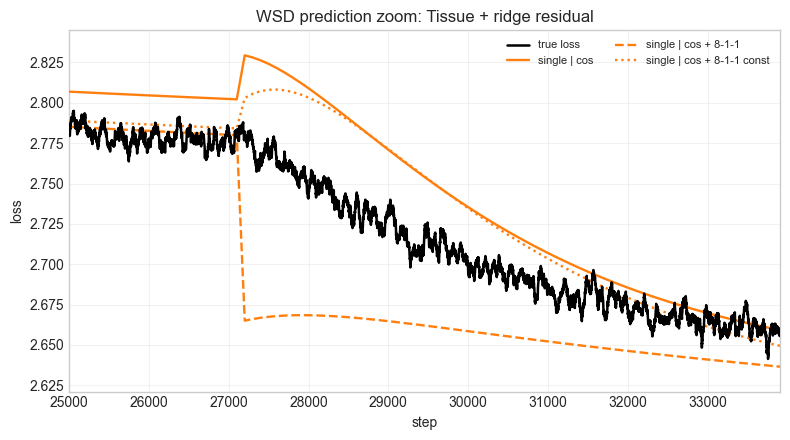

In [41]:
fig, ax = plot_fit_zoom_compare(
    fit_groups=ridge_fit_groups,
    curve=wsd_curve,
    every=EVAL_EVERY,
    start_step=FIT_START,
    device=DEVICE,
    zoom_start=25000,
    figsize=(8, 4.5),
    title="WSD prediction zoom: Tissue + ridge residual",
    setting_linestyles=ridge_setting_linestyles,
)

fig.savefig(FIG_DIR / "ridge_single_wsd_prediction_zoom.png", dpi=200, bbox_inches="tight")
plt.show()

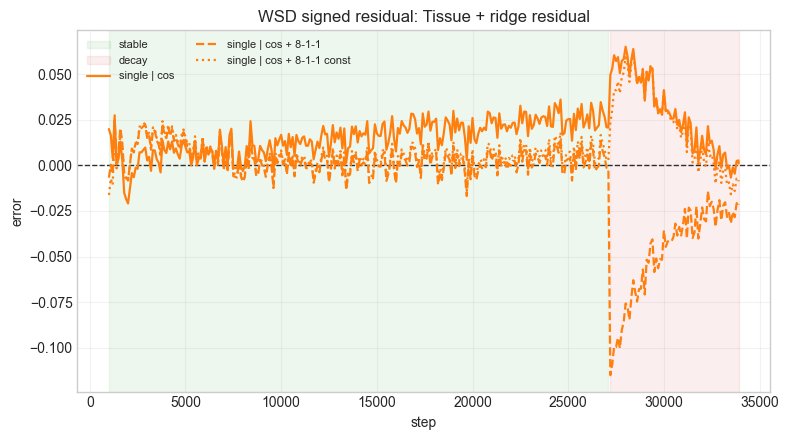

In [42]:
fig, ax = plot_error_compare(
    pred_groups=ridge_pred_groups,
    curve_label="wsd",
    error_col="error",
    phase_col="phase",
    figsize=(8, 4.5),
    title="WSD signed residual: Tissue + ridge residual",
    setting_linestyles=ridge_setting_linestyles,
    phase_colors={
        "stable": "tab:green",
        "decay": "tab:red",
        "not_wsd": "tab:gray",
        "unknown": "tab:gray",
    },
)

fig.savefig(FIG_DIR / "ridge_single_wsd_signed_residual.png", dpi=200, bbox_inches="tight")
plt.show()

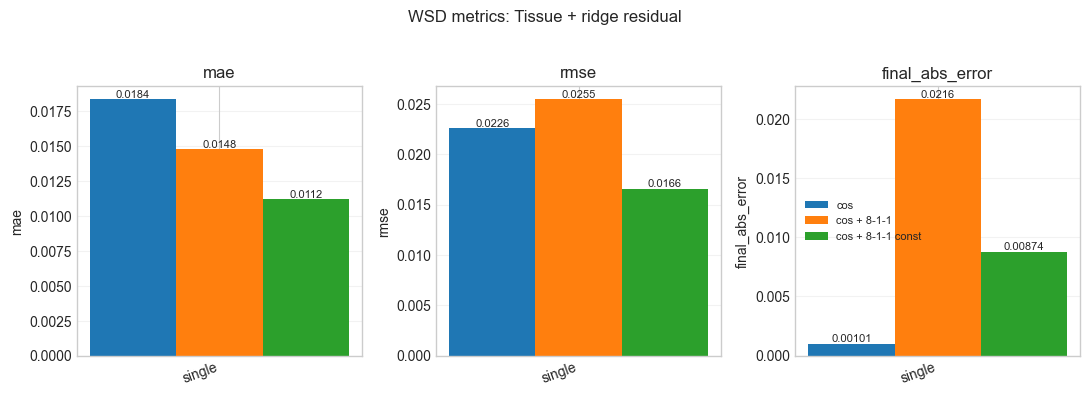

In [43]:
fig, axes = plot_metric_compare_bars(
    metrics_by_setting=ridge_metrics_by_setting,
    curve_label="wsd",
    metric_cols=("mae", "rmse", "final_abs_error"),
    method_order=("single",),
    figsize=(11, 3.8),
    title="WSD metrics: Tissue + ridge residual",
)

fig.savefig(FIG_DIR / "ridge_single_wsd_metrics_bar.png", dpi=200, bbox_inches="tight")
plt.show()

### 7.3 Compare ridge correction with uncorrected Tissue law


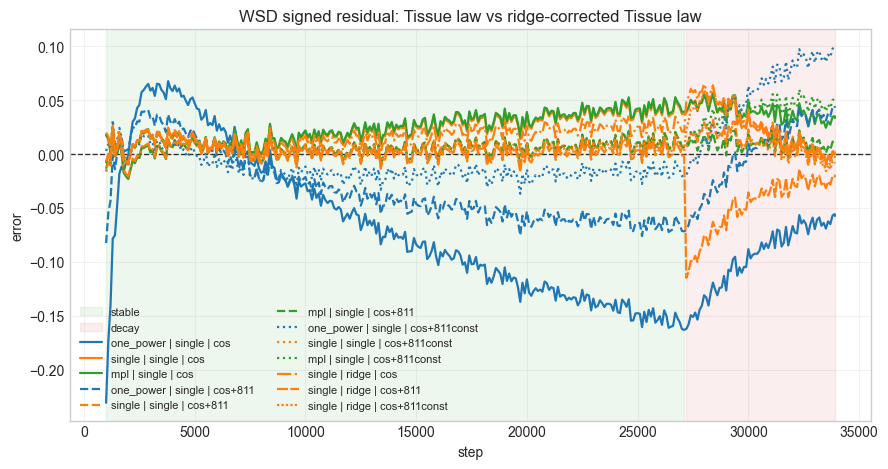

In [44]:
tissue_vs_ridge_pred_groups = {
    "single | cos": pred_df_cos if "pred_df_cos" in globals() else pred_df[pred_df["source_key"] == wsd_name].copy(),
    "single | cos+811": pred_df_cos_811_full,
    "single | cos+811const": pred_df_cos_811_const,
    "ridge | cos": pred_df_ridge_cos,
    "ridge | cos+811": pred_df_ridge_cos811,
    "ridge | cos+811const": pred_df_ridge_cos811const,
}

tissue_vs_ridge_linestyles = {
    "single | cos": "-",
    "single | cos+811": "--",
    "single | cos+811const": ":",
    "ridge | cos": "-.",
    "ridge | cos+811": (0, (5, 1)),
    "ridge | cos+811const": (0, (1, 1)),
}

fig, ax = plot_error_compare(
    pred_groups=tissue_vs_ridge_pred_groups,
    curve_label="wsd",
    error_col="error",
    phase_col="phase",
    figsize=(9, 4.8),
    title="WSD signed residual: Tissue law vs ridge-corrected Tissue law",
    setting_linestyles=tissue_vs_ridge_linestyles,
    phase_colors={
        "stable": "tab:green",
        "decay": "tab:red",
        "not_wsd": "tab:gray",
        "unknown": "tab:gray",
    },
)

fig.savefig(FIG_DIR / "ridge_vs_uncorrected_single_wsd_signed_residual.png", dpi=200, bbox_inches="tight")
plt.show()

**Interpretation.**

The ridge correction only slightly improves over the One-Power baseline and remains worse than the original Tissue-style cosine-only model. This suggests that generic linear schedule features cannot replace the structured \(S_2\)-based annealing term.
